In [7]:

import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch import nn
from datasets import load_dataset, Dataset

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback
)

from sklearn.metrics import f1_score, classification_report
from scipy.stats import pearsonr



In [8]:
from google.colab import drive
drive.mount('/content/drive')

LOG_FILE = "/content/drive/MyDrive/RoBERTa_SingleStep_log.csv"

os.makedirs("/content/drive/MyDrive", exist_ok=True)

with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

   
    writer.writerow(["model", "roberta-base"])
    writer.writerow(["learning_rate", 2e-5])
    writer.writerow(["train_batch_size", 8])
    writer.writerow(["eval_batch_size", 4])
    writer.writerow(["epochs", 10])
    writer.writerow([])

# =========================================================
# 2. SEED SETUP
# =========================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# =========================================================
# 3. LOAD BRIGHTER DATASET
# =========================================================
print("\nLoading BRIGHTER dataset from Hugging Face...")

train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data   = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data  = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("\nOriginal split sizes:")
print("Train:", len(train_df))
print("Dev  :", len(val_df))
print("Test :", len(test_df))

print("\nSample data:")
print(train_df.head())



# =========================================================
# 4. LABEL CONFIGURATION
# =========================================================
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
LEVELS = [1, 2, 3]

LABELS = [f"{emotion}_{level}" for emotion in EMOTIONS for level in LEVELS]
NUM_LABELS = len(LABELS)

print("\nLabels:")
print(LABELS)
print("Number of labels:", NUM_LABELS)


# =========================================================
# 5. CONVERT LABELS TO SINGLE-STEP FORMAT
# =========================================================
def convert_single_step_labels(df):
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    for emotion in EMOTIONS:
        df[f"{emotion}_1"] = (df[emotion] == 1).astype(int)
        df[f"{emotion}_2"] = (df[emotion] == 2).astype(int)
        df[f"{emotion}_3"] = (df[emotion] == 3).astype(int)

    return df


train_single = convert_single_step_labels(train_df)
val_single = convert_single_step_labels(val_df)
test_single = convert_single_step_labels(test_df)

print("\nSingle-step sample:")
print(train_single[["text"] + LABELS].head())


# =========================================================
# 6. COMBINE AND REDISTRIBUTE DATASET: 70 / 20 / 10
# =========================================================
full_df = pd.concat(
    [train_single, val_single, test_single],
    ignore_index=True
)

full_df = full_df[["text"] + LABELS]

full_df = full_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

n = len(full_df)

train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_single = full_df[:train_end]
val_single = full_df[train_end:val_end]
test_single = full_df[val_end:]

print("\nRedistributed split sizes:")
print({
    "train": len(train_single),
    "val": len(val_single),
    "test": len(test_single)
})

test_texts = test_single["text"].tolist()


# =========================================================
# 7. CONVERT TO HUGGING FACE DATASET
# =========================================================
train_single = Dataset.from_pandas(train_single, preserve_index=False)
val_single = Dataset.from_pandas(val_single, preserve_index=False)
test_single = Dataset.from_pandas(test_single, preserve_index=False)


# =========================================================
# 8. TOKENIZATION
# =========================================================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_single = train_single.map(tokenize_function, batched=True)
val_single = val_single.map(tokenize_function, batched=True)
test_single = test_single.map(tokenize_function, batched=True)


# =========================================================
# 9. ADD LABEL VECTOR
# =========================================================
def add_labels(example):
    example["labels"] = [float(example[label]) for label in LABELS]
    return example

train_single = train_single.map(add_labels)
val_single = val_single.map(add_labels)
test_single = test_single.map(add_labels)

train_single.set_format(type="torch",columns=["input_ids", "attention_mask", "labels"])
val_single.set_format(type="torch",columns=["input_ids", "attention_mask", "labels"])
test_single.set_format(type="torch",columns=["input_ids", "attention_mask", "labels"])





Loading BRIGHTER dataset from Hugging Face...

Original split sizes:
Train: 2763
Dev  : 115
Test : 2765

Sample data:
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  

Labels:
['anger_1', 'anger_2', 'anger_3', 'fear_1', 'fear_2', 'fear_3', 'joy_1', 'joy_2', 'jo

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

In [10]:
# =========================================================
# 10. METRICS
# =========================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    f1_micro = f1_score(
        labels,
        preds,
        average="micro",
        zero_division=0
    )

    pearsons = []

    for i in range(labels.shape[1]):
        if np.std(labels[:, i]) == 0 or np.std(probs[:, i]) == 0:
            pearsons.append(0.0)
        else:
            p, _ = pearsonr(labels[:, i], probs[:, i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    pearson_mean = float(np.mean(pearsons))

    return {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pearson_mean": pearson_mean
    }


# =========================================================
# 12. LISTS FOR PLOTTING
# =========================================================
epoch_list = []

train_loss_list = []

val_loss_list = []
val_f1_macro_list = []
val_f1_micro_list = []
val_pearson_mean_list = []

test_loss_list = []
test_f1_macro_list = []
test_f1_micro_list = []
test_pearson_mean_list = []


# =========================================================
# 13. CALLBACK FOR EPOCH LOGGING
# =========================================================
class SaveEpochResultsCallback(TrainerCallback):
    def __init__(self, file_path, test_dataset):
        self.file_path = file_path
        self.test_dataset = test_dataset

        self.trainer_ref = None
        self.current_train_loss = None
        self._inside_eval = False

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if self._inside_eval:
            return

        if metrics is None:
            return

        self._inside_eval = True

        epoch = int(round(float(metrics.get("epoch", state.epoch))))

        train_loss = (
            self.current_train_loss
            if self.current_train_loss is not None
            else ""
        )

        val_loss = float(metrics.get("eval_loss", 0.0))
        val_f1_macro = float(metrics.get("eval_f1_macro", 0.0))
        val_f1_micro = float(metrics.get("eval_f1_micro", 0.0))
        val_pearson_mean = float(metrics.get("eval_pearson_mean", 0.0))

        test_results = self.trainer_ref.evaluate(
            eval_dataset=self.test_dataset,
            metric_key_prefix="test"
        )

        test_loss = float(test_results.get("test_loss", 0.0))
        test_f1_macro = float(test_results.get("test_f1_macro", 0.0))
        test_f1_micro = float(test_results.get("test_f1_micro", 0.0))
        test_pearson_mean = float(test_results.get("test_pearson_mean", 0.0))

        epoch_list.append(epoch)

        train_loss_list.append(train_loss)

        val_loss_list.append(val_loss)
        val_f1_macro_list.append(val_f1_macro)
        val_f1_micro_list.append(val_f1_micro)
        val_pearson_mean_list.append(val_pearson_mean)

        test_loss_list.append(test_loss)
        test_f1_macro_list.append(test_f1_macro)
        test_f1_micro_list.append(test_f1_micro)
        test_pearson_mean_list.append(test_pearson_mean)

        pred = self.trainer_ref.predict(self.test_dataset)

        logits = pred.predictions
        true_labels = pred.label_ids

        probs = 1 / (1 + np.exp(-logits))
        pred_labels = (probs >= 0.5).astype(int)

        report_dict = classification_report(
            true_labels,
            pred_labels,
            target_names=LABELS,
            zero_division=0,
            output_dict=True
        )

        with open(self.file_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)

            # -------------------------
            # EPOCH HEADER
            # -------------------------
            writer.writerow([])
            writer.writerow([f"EPOCH {epoch}"])

            # -------------------------
            # CUMULATIVE EPOCH TABLE
            # -------------------------
            writer.writerow([
                "epoch",
                "train_loss",
                "val_loss",
                "test_loss",
                "val_f1_macro",
                "val_f1_micro",
                "test_f1_macro",
                "test_f1_micro",
                "val_pearson_mean",
                "test_pearson_mean"
            ])

            for i in range(len(epoch_list)):
                writer.writerow([
                    epoch_list[i],
                    train_loss_list[i],
                    val_loss_list[i],
                    test_loss_list[i],
                    val_f1_macro_list[i],
                    val_f1_micro_list[i],
                    test_f1_macro_list[i],
                    test_f1_micro_list[i],
                    val_pearson_mean_list[i],
                    test_pearson_mean_list[i]
                ])

            # -------------------------
            # FINAL TEST SCORES AFTER THIS EPOCH
            # -------------------------
            writer.writerow([])
            writer.writerow([f"FINAL TEST SCORES AFTER EPOCH {epoch}"])
            writer.writerow(["metric", "value"])
            writer.writerow(["test_loss", test_loss])
            writer.writerow(["test_f1_macro", test_f1_macro])
            writer.writerow(["test_f1_micro", test_f1_micro])
            writer.writerow(["test_pearson_mean", test_pearson_mean])

            # -------------------------
            # CLASSWISE RESULTS AFTER THIS EPOCH
            # -------------------------
            writer.writerow([])
            writer.writerow([f"CLASSWISE RESULTS AFTER EPOCH {epoch}"])
            writer.writerow([
                "class",
                "precision",
                "recall",
                "f1_score",
                "support"
            ])

            for class_name in LABELS:
                row = report_dict.get(class_name, {})

                writer.writerow([
                    class_name,
                    row.get("precision", ""),
                    row.get("recall", ""),
                    row.get("f1-score", ""),
                    row.get("support", "")
                ])

        print(f"\nEpoch {epoch} cumulative losses, final test scores, and classwise results saved.")

        self._inside_eval = False





In [11]:


# =========================================================
# 15. MODEL
# =========================================================
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)


# =========================================================
# 16. TRAINING ARGUMENTS
# =========================================================
training_args = TrainingArguments(
    output_dir="/content/roberta_output",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,

    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)


callback = SaveEpochResultsCallback(
    file_path=LOG_FILE,
    test_dataset=test_single
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_single,
    eval_dataset=val_single,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[callback]
)

callback.trainer_ref = trainer


# =========================================================
# 17. TRAIN
# =========================================================
start = time.time()

trainer.train()

end = time.time()

print(f"\nTotal training time: {end - start:.1f} seconds")
print("Epochwise result file saved at:", LOG_FILE)




Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Pearson Mean
1,0.309047,0.266717,0.003150,0.005672,0.304494
2,0.250320,0.244679,0.139292,0.175355,0.409351
3,0.214013,0.235606,0.186951,0.250757,0.443663
4,0.185669,0.230141,0.284479,0.394044,0.464062
5,0.158414,0.234446,0.324198,0.415584,0.468396
6,0.136260,0.244023,0.368060,0.451432,0.469082
7,0.119111,0.250513,0.366122,0.452641,0.464608
8,0.103434,0.254535,0.377109,0.442665,0.458279
9,0.091822,0.263639,0.396210,0.460155,0.458877
10,0.085548,0.265536,0.387118,0.457987,0.461231



Epoch 1 cumulative losses, final test scores, and classwise results saved.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 10 cumulative losses, final test scores, and classwise results saved.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Total training time: 586.1 seconds
Epochwise result file saved at: /content/drive/MyDrive/RoBERTa_SingleStep_log.csv


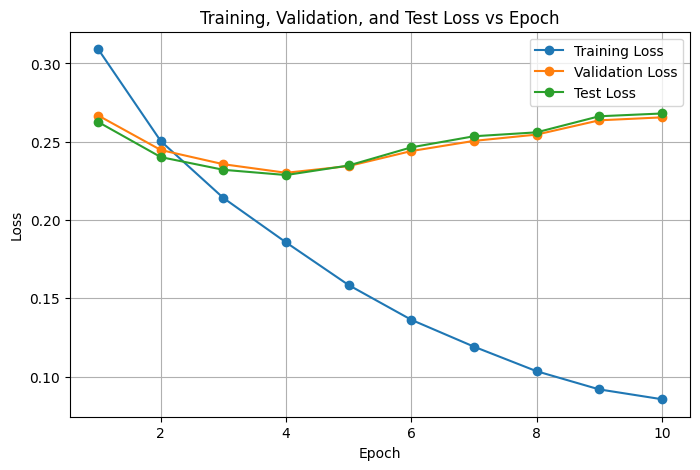

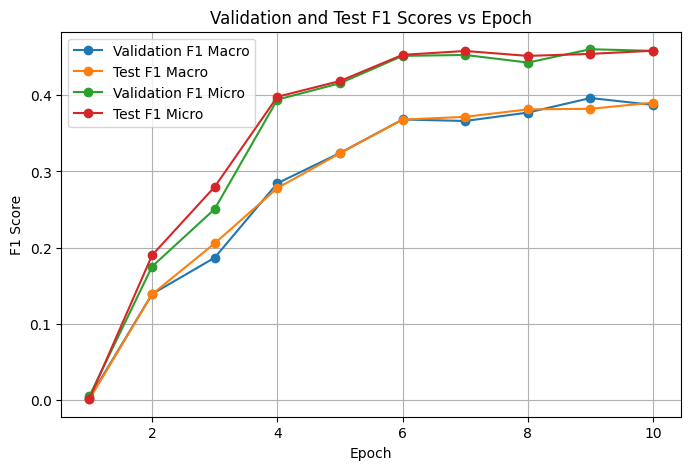

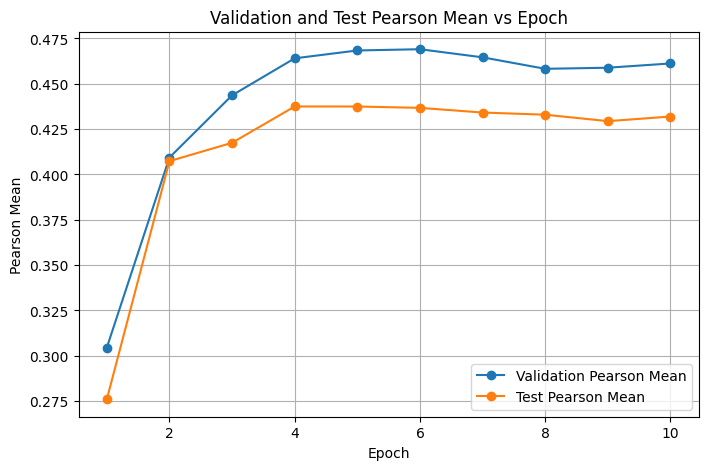

In [12]:
# =========================================================
# 18. PLOTS
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, train_loss_list, marker="o", label="Training Loss")
plt.plot(epoch_list, val_loss_list, marker="o", label="Validation Loss")
plt.plot(epoch_list, test_loss_list, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epoch_list, val_f1_macro_list, marker="o", label="Validation F1 Macro")
plt.plot(epoch_list, test_f1_macro_list, marker="o", label="Test F1 Macro")
plt.plot(epoch_list, val_f1_micro_list, marker="o", label="Validation F1 Micro")
plt.plot(epoch_list, test_f1_micro_list, marker="o", label="Test F1 Micro")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation and Test F1 Scores vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epoch_list, val_pearson_mean_list, marker="o", label="Validation Pearson Mean")
plt.plot(epoch_list, test_pearson_mean_list, marker="o", label="Test Pearson Mean")
plt.xlabel("Epoch")
plt.ylabel("Pearson Mean")
plt.title("Validation and Test Pearson Mean vs Epoch")
plt.legend()
plt.grid(True)
plt.show()